In [ ]:
!pip install twstock
!pip install pandas
!pip install plotly
!pip install matplotlib
!pip install yfinance
!pip install mplfinance yfinance
!pip install yfinance mplfinance pandas

In [ ]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

def get_stock_data(stock_code):
    ticker = yf.Ticker(stock_code)

    # 取得最近7天資料
    end_date = datetime.today()
    start_date = end_date - timedelta(days=7)
    df = ticker.history(start=start_date, end=end_date)

    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

    # 取得公司資訊
    info = ticker.info
    market_cap = info.get("marketCap", None)
    shares_outstanding = info.get("sharesOutstanding", None)

    # 加入市值與股本（同一值填整欄）
    df['Market Cap'] = market_cap
    df['Shares Outstanding'] = shares_outstanding
    return df

stock_code = "2330.TW"  # 台積電
data = get_stock_data(stock_code)
# 設定不換行，並自動偵測螢幕寬度
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)

print(data)


In [ ]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta



# ===== RSI 計算 =====
def calculate_rsi(data, window=14):
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# ===== 主函數 =====
def get_tsmc_data():
    stock = "2330.TW"  # 台積電
    ticker = yf.Ticker(stock)

    # 抓最近1個月（確保RSI能算）
    df = ticker.history(period="1mo")
    # ===== 價格資料 =====
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    # ===== 技術指標 =====
    df['MA5'] = df['Close'].rolling(5).mean()
    df['MA20'] = df['Close'].rolling(20).mean()
    df['RSI'] = calculate_rsi(df)
    # ===== 基本面 =====
    info = ticker.info
    pe = info.get("trailingPE")
    eps = info.get("trailingEps")
    df['PE'] = pe
    df['EPS'] = eps
    return df
# ===== 執行 =====
df = get_tsmc_data()
print(df.tail(10))

                                  Open         High     Low   Close    Volume          MA5         MA20        RSI         PE    EPS
Date                                                                                                                                
2026-03-16 00:00:00+08:00  1868.902439  1873.886179  1839.0  1839.0  31249086  1870.895923          NaN        NaN  27.475847  66.24
2026-03-17 00:00:00+08:00  1875.000000  1880.000000  1860.0  1870.0  23812211  1876.099170          NaN        NaN  27.475847  66.24
2026-03-18 00:00:00+08:00  1900.000000  1910.000000  1890.0  1905.0  23068156  1870.360962          NaN        NaN  27.475847  66.24
2026-03-19 00:00:00+08:00  1875.000000  1880.000000  1850.0  1850.0  31040569  1864.586987          NaN  39.769077  27.475847  66.24
2026-03-20 00:00:00+08:00  1860.000000  1870.000000  1840.0  1840.0  46312322  1860.800000          NaN  39.094458  27.475847  66.24
2026-03-23 00:00:00+08:00  1790.000000  1815.000000  1785.0  1810.0  


========== 2330.TW ==========



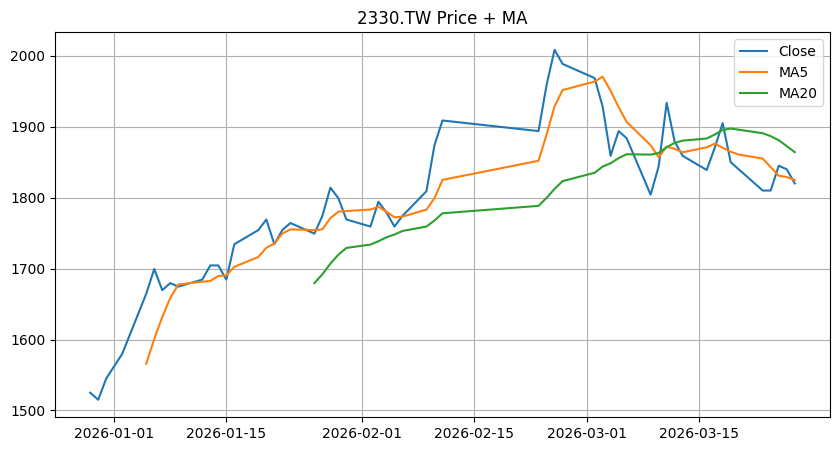

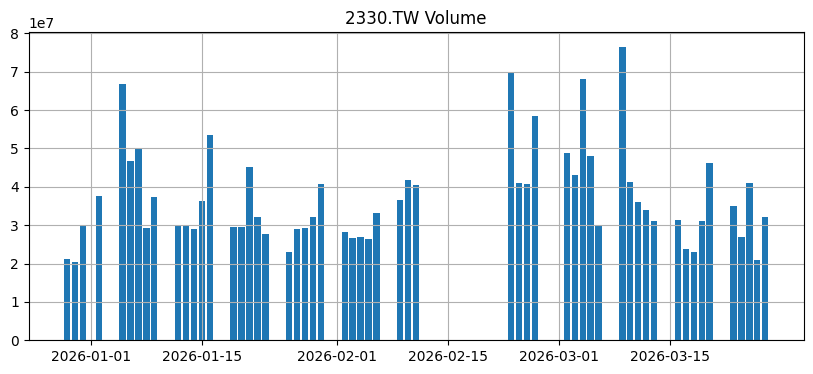

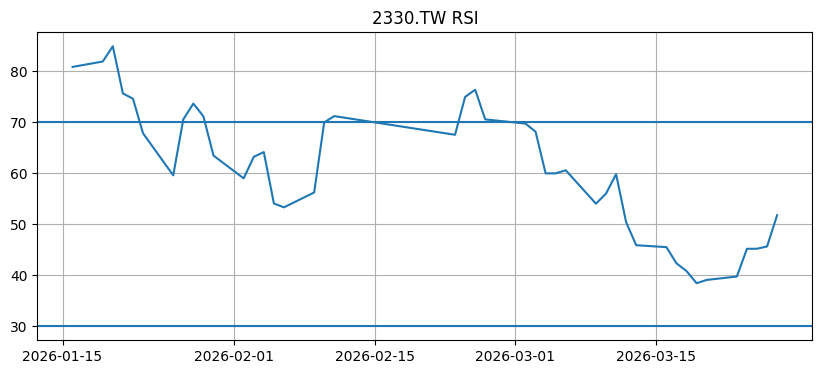

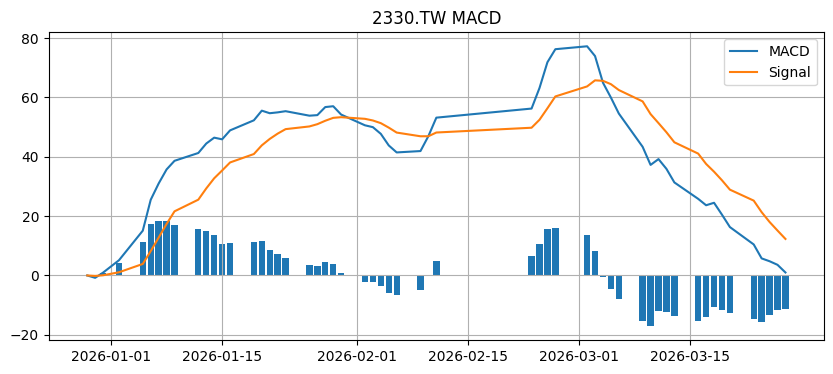

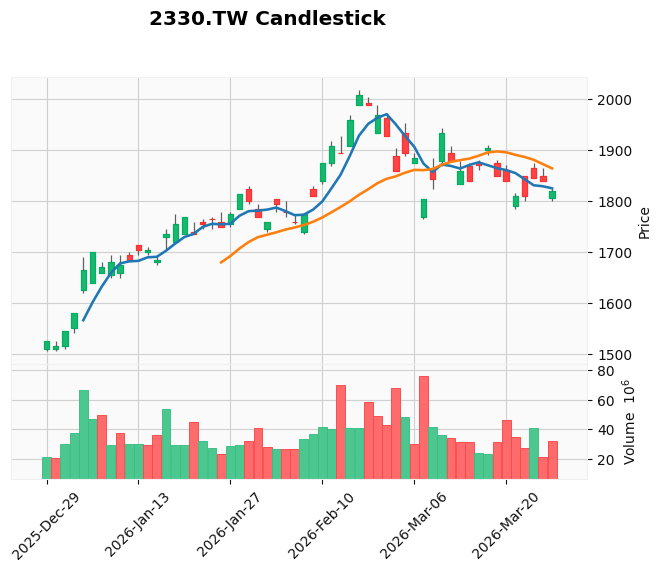


========== 2454.TW ==========



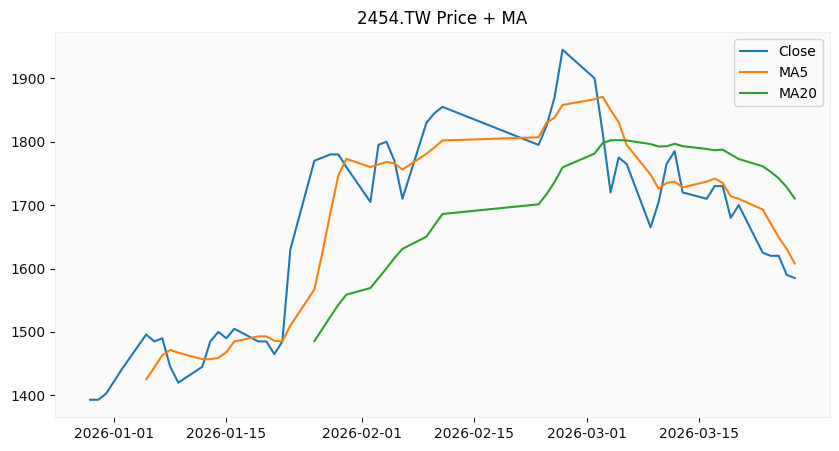

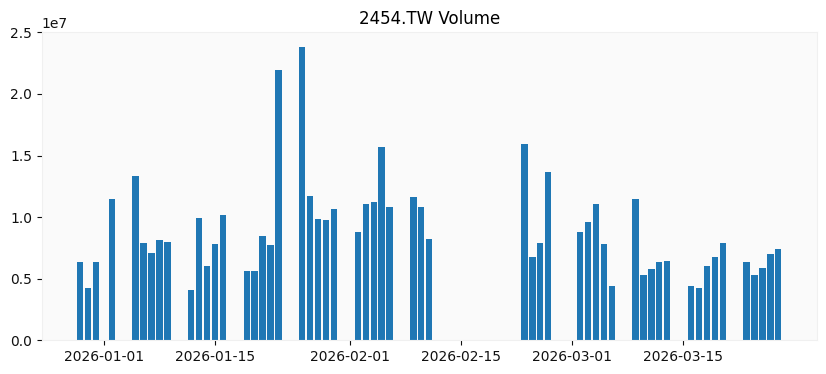

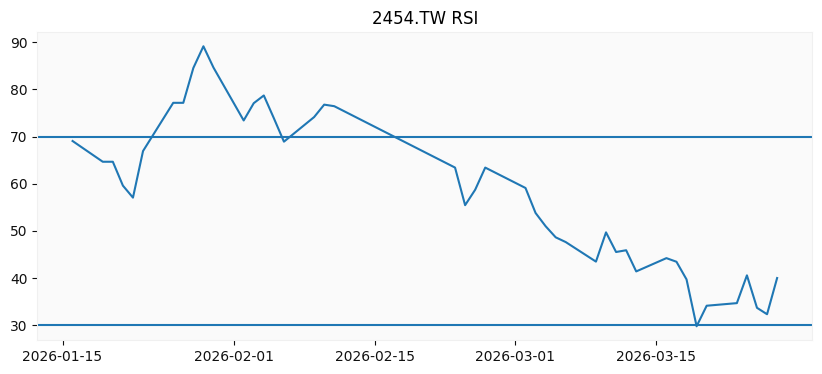

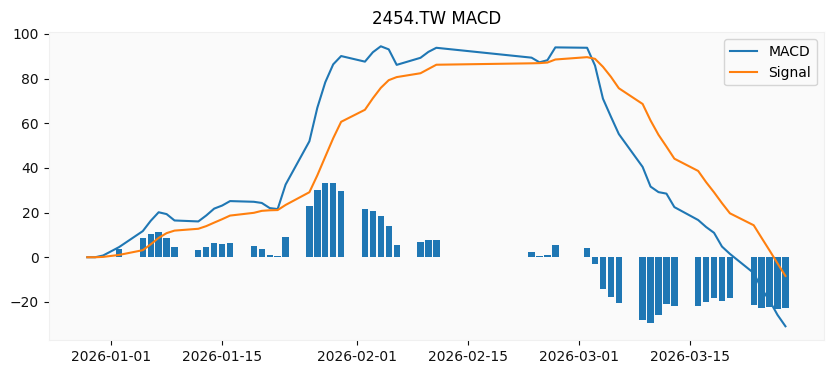

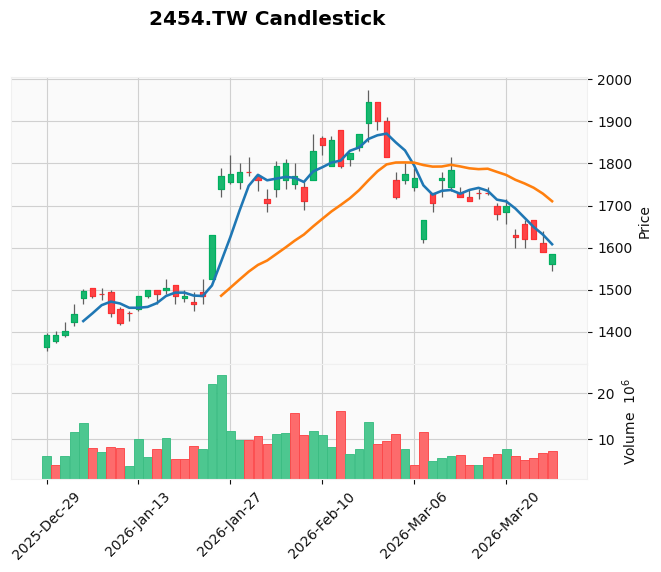


========== 3035.TW ==========



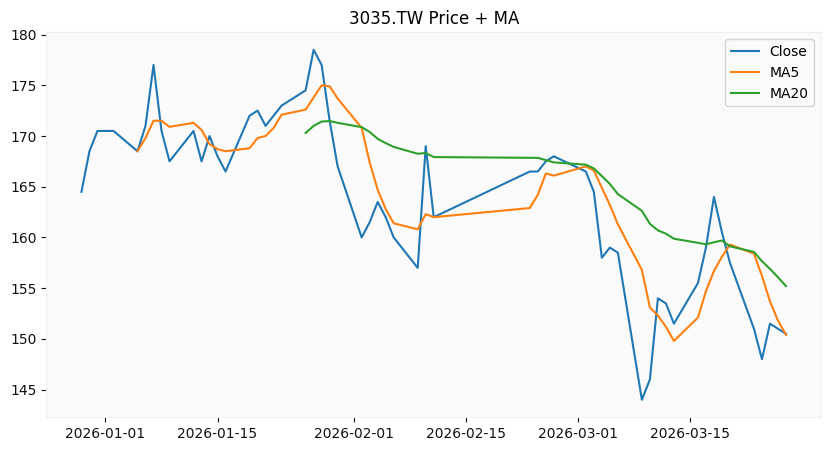

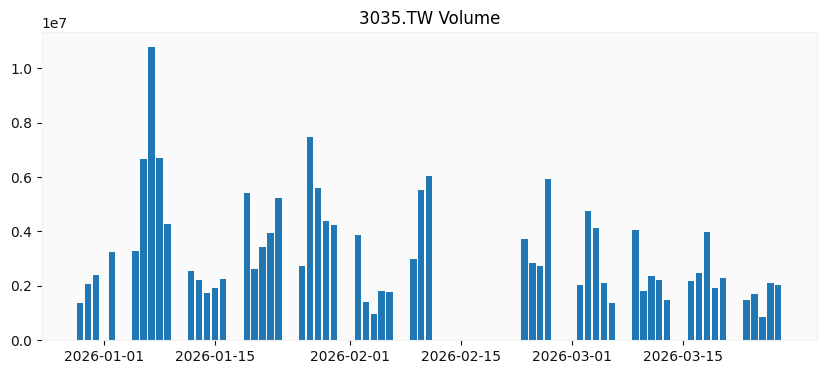

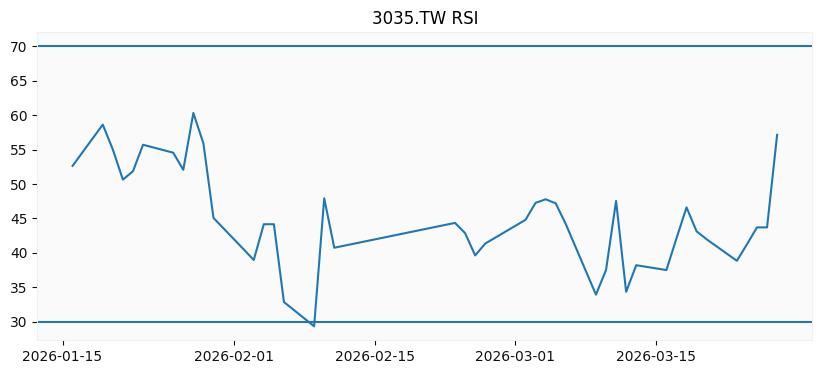

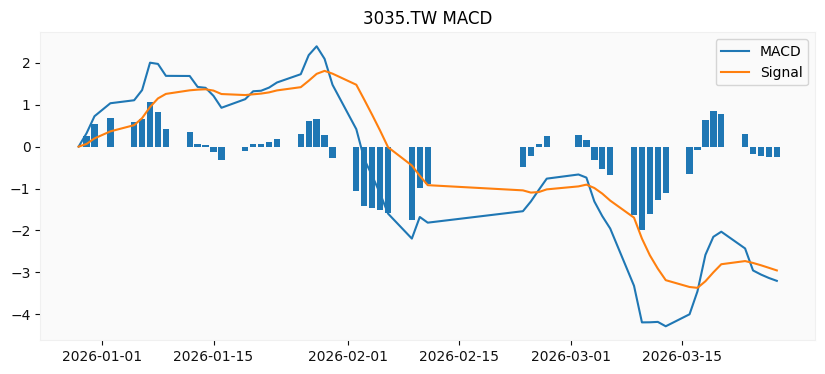

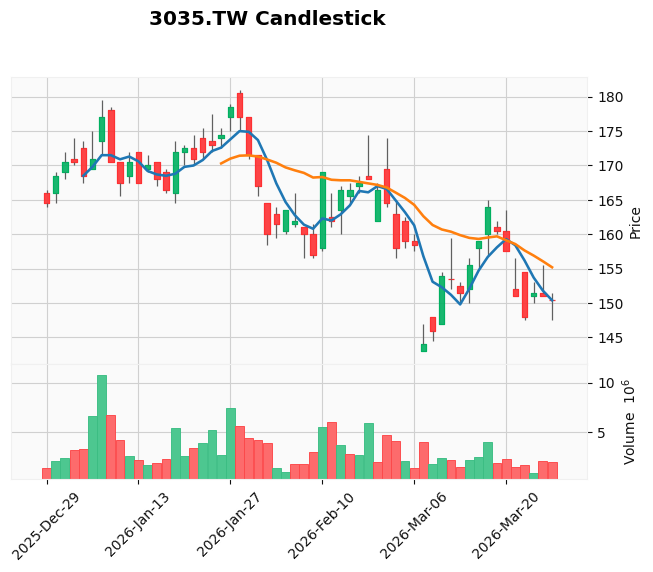

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf

# =========================
# RSI
# =========================
def calculate_rsi(data, window=14):
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

# =========================
# MACD
# =========================
def calculate_macd(data):
    ema12 = data['Close'].ewm(span=12, adjust=False).mean()
    ema26 = data['Close'].ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26
    signal = macd.ewm(span=9, adjust=False).mean()
    hist = macd - signal
    return macd, signal, hist

# =========================
# ⭐ 股票清單（自己改這裡）
# =========================
stocks = ["2330.TW", "2454.TW", "3035.TW"]

# =========================
# 主流程
# =========================
for stock in stocks:

    print(f"\n========== {stock} ==========\n")
    ticker = yf.Ticker(stock)
    df = ticker.history(period="3mo")
    df = df[['Open','High','Low','Close','Volume']]

    # ===== 技術指標 =====
    df['MA5'] = df['Close'].rolling(5).mean()
    df['MA20'] = df['Close'].rolling(20).mean()
    df['RSI'] = calculate_rsi(df)

    macd, signal, hist = calculate_macd(df)
    df['MACD'] = macd
    df['Signal'] = signal
    df['Hist'] = hist
    # =========================
    # 📈 圖1：價格 + MA
    # =========================
    plt.figure(figsize=(10,5))
    plt.plot(df.index, df['Close'], label='Close')
    plt.plot(df.index, df['MA5'], label='MA5')
    plt.plot(df.index, df['MA20'], label='MA20')

    plt.title(f"{stock} Price + MA")
    plt.legend()
    plt.grid()
    plt.show()

    # =========================
    # 📊 圖2：Volume
    # =========================
    plt.figure(figsize=(10,4))
    plt.bar(df.index, df['Volume'])

    plt.title(f"{stock} Volume")
    plt.grid()
    plt.show()

    # =========================
    # 📉 圖3：RSI
    # =========================
    plt.figure(figsize=(10,4))
    plt.plot(df.index, df['RSI'])

    plt.axhline(70)
    plt.axhline(30)

    plt.title(f"{stock} RSI")
    plt.grid()
    plt.show()

    # =========================
    # 📊 圖4：MACD
    # =========================
    plt.figure(figsize=(10,4))
    plt.plot(df.index, df['MACD'], label='MACD')
    plt.plot(df.index, df['Signal'], label='Signal')
    plt.bar(df.index, df['Hist'])

    plt.title(f"{stock} MACD")
    plt.legend()
    plt.grid()
    plt.show()

    # =========================
    # 🕯️ 圖5：K線
    # =========================
    df_k = df[['Open','High','Low','Close','Volume']]

    mpf.plot(
        df_k,
        type='candle',
        mav=(5,20),
        volume=True,
        style='yahoo',
        title=f"{stock} Candlestick"
    )

請輸入股票代碼（用逗號分隔，例如 2330.TW,2454.TW,AAPL）：
2330.TW, 2454.TW, 3035.TW

========== 2330.TW ==========



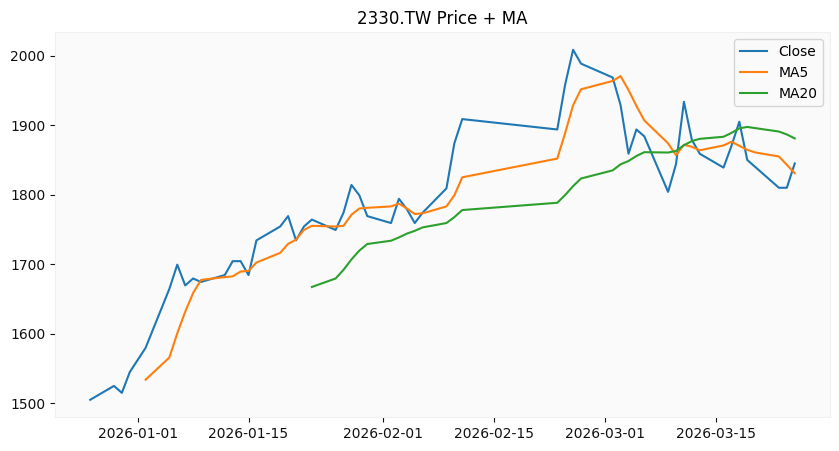

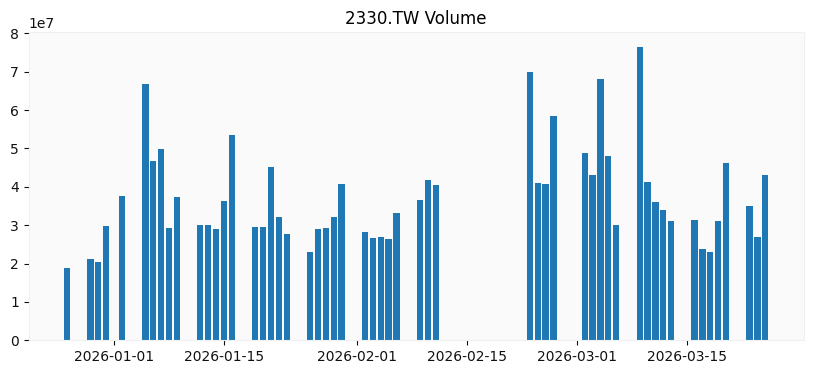

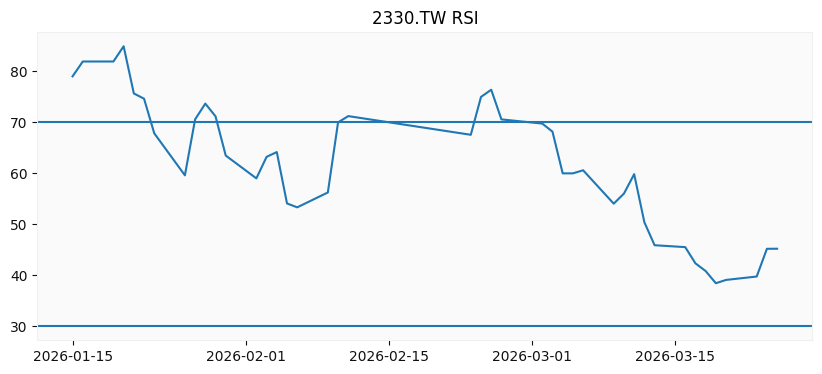

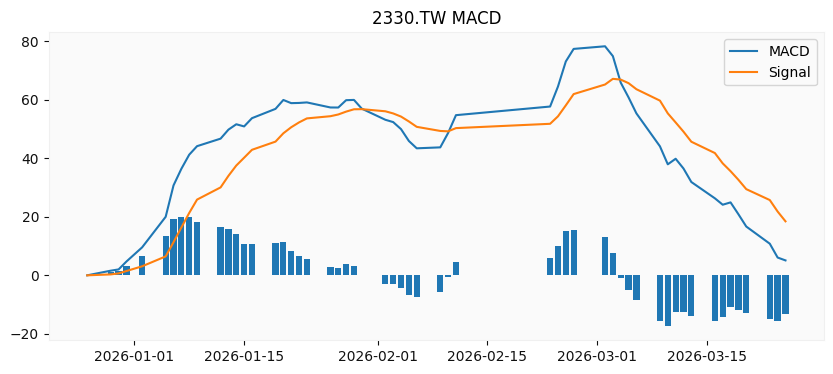

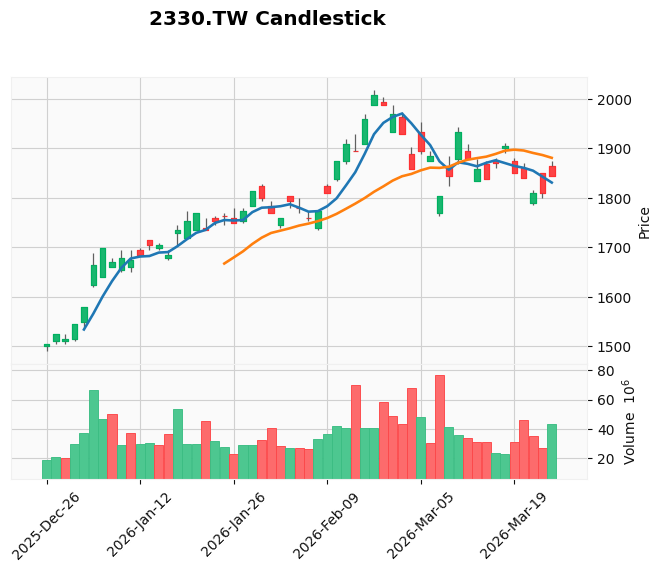


📊 分析結果：2330.TW
Score: -1
👉 建議：觀望（Hold）
- 下降趨勢（MA5 < MA20）
- 未過熱（RSI < 70）
- 動能轉弱（MACD < Signal）

========== 2454.TW ==========



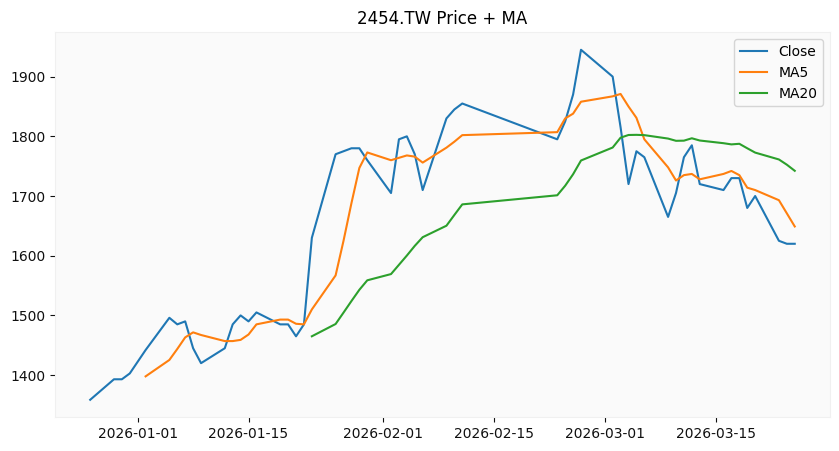

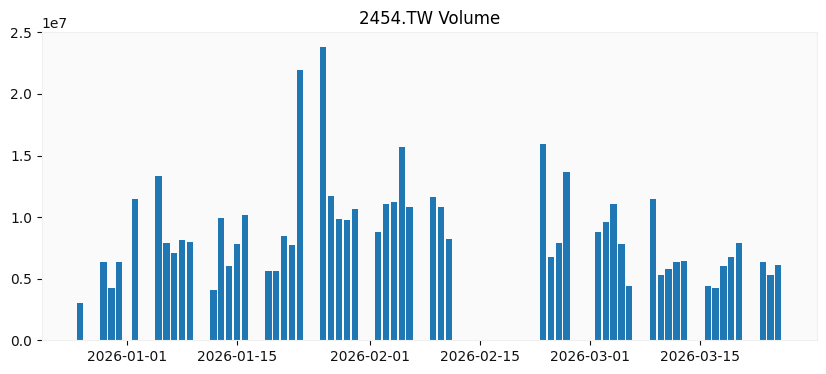

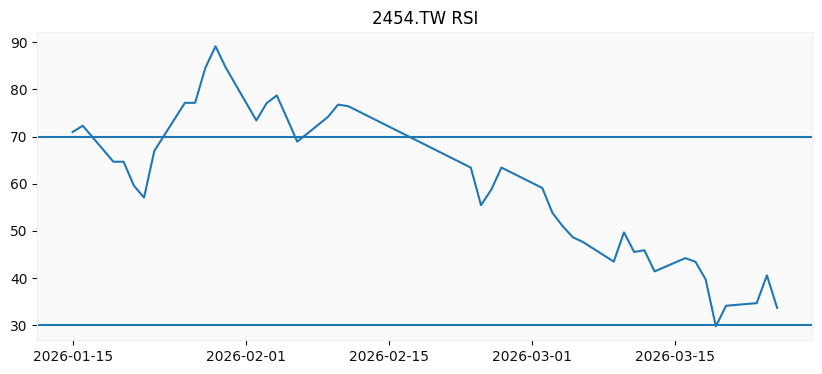

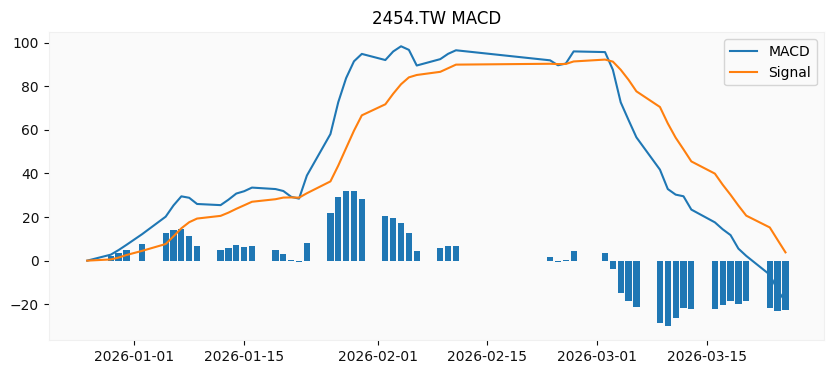

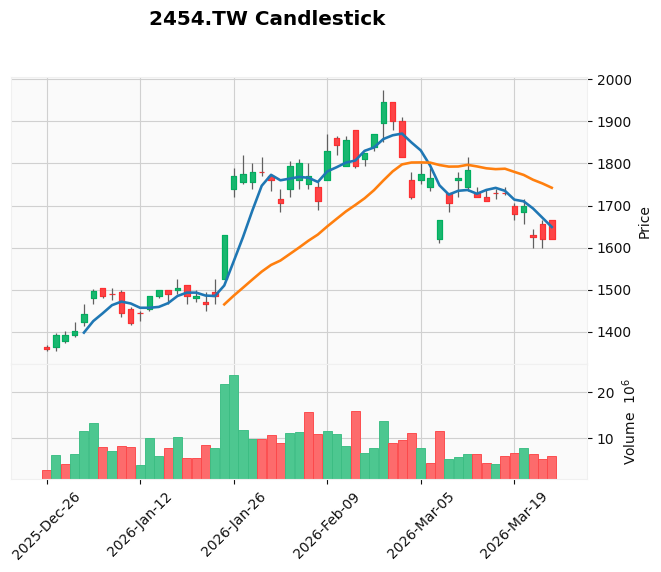


📊 分析結果：2454.TW
Score: -1
👉 建議：觀望（Hold）
- 下降趨勢（MA5 < MA20）
- 未過熱（RSI < 70）
- 動能轉弱（MACD < Signal）

========== 3035.TW ==========



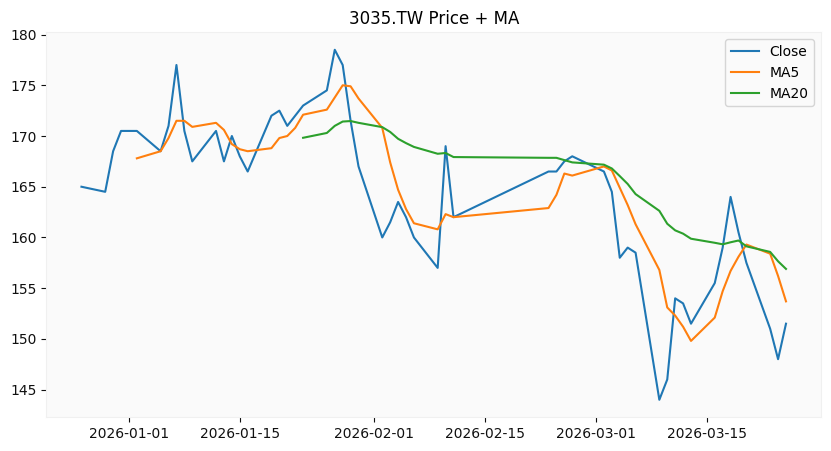

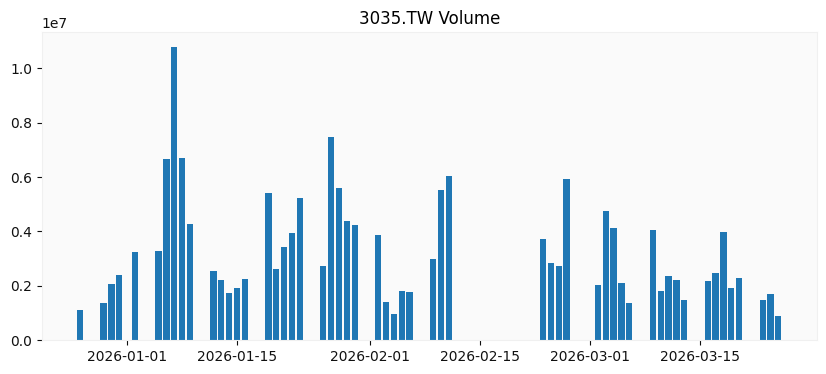

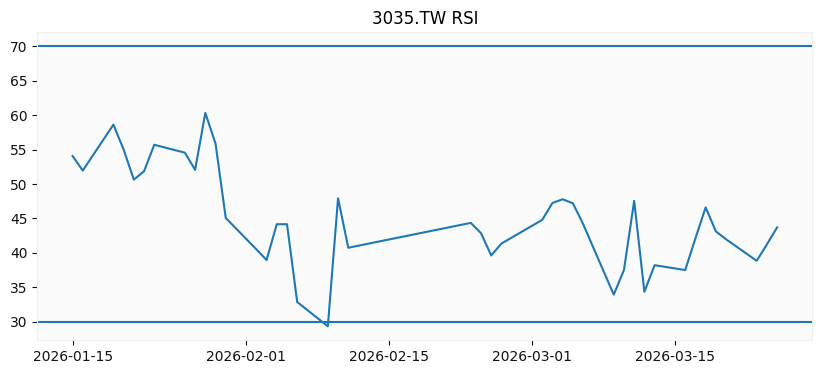

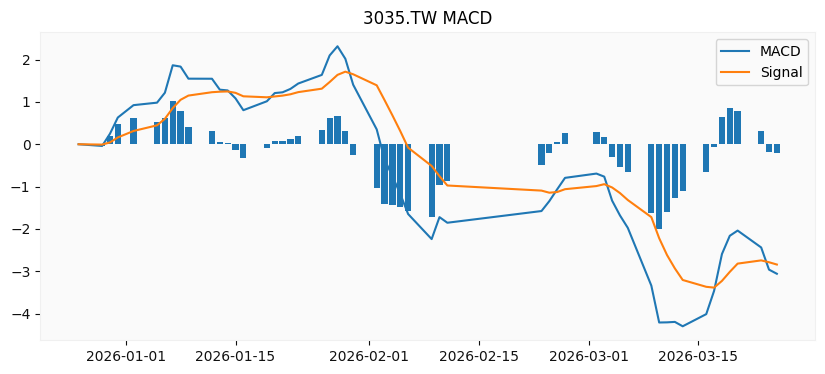

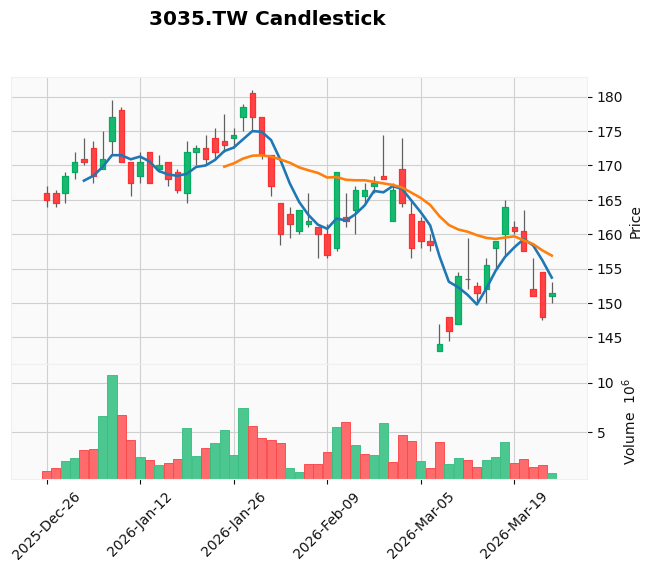


📊 分析結果：3035.TW
Score: -1
👉 建議：觀望（Hold）
- 下降趨勢（MA5 < MA20）
- 未過熱（RSI < 70）
- 動能轉弱（MACD < Signal）

📊 最終推薦排名
2330.TW → Score: -1
2454.TW → Score: -1
3035.TW → Score: -1


In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf

# =========================
# RSI
# =========================
def calculate_rsi(data, window=14):
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

# =========================
# MACD
# =========================
def calculate_macd(data):
    ema12 = data['Close'].ewm(span=12, adjust=False).mean()
    ema26 = data['Close'].ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26
    signal = macd.ewm(span=9, adjust=False).mean()
    hist = macd - signal
    return macd, signal, hist

# =========================
# 評分系統
# =========================
def analyze_stock(df):
    latest = df.iloc[-1]
    score = 0
    reasons = []

    if latest['MA5'] > latest['MA20']:
        score += 1
        reasons.append("上升趨勢（MA5 > MA20）")
    else:
        score -= 1
        reasons.append("下降趨勢（MA5 < MA20）")

    if latest['RSI'] < 70:
        score += 1
        reasons.append("未過熱（RSI < 70）")
    else:
        score -= 1
        reasons.append("過熱（RSI > 70）")

    if latest['MACD'] > latest['Signal']:
        score += 1
        reasons.append("動能向上（MACD > Signal）")
    else:
        score -= 1
        reasons.append("動能轉弱（MACD < Signal）")

    return score, reasons

# =========================
# 股票清單
# =========================
# =========================
# 使用者輸入股票
# =========================
user_input = input("請輸入股票代碼（用逗號分隔，例如 2330.TW,2454.TW,AAPL）：\n")

stocks = [s.strip() for s in user_input.split(",")]
# stocks = ["2330.TW", "2454.TW", "3035.TW"]

results = []

# =========================
# 主程式
# =========================
for stock in stocks:

    print(f"\n========== {stock} ==========\n")

    ticker = yf.Ticker(stock)
    df = ticker.history(period="3mo")

    df = df[['Open','High','Low','Close','Volume']]

    # 技術指標
    df['MA5'] = df['Close'].rolling(5).mean()
    df['MA20'] = df['Close'].rolling(20).mean()
    df['RSI'] = calculate_rsi(df)

    macd, signal, hist = calculate_macd(df)
    df['MACD'] = macd
    df['Signal'] = signal
    df['Hist'] = hist

    # =========================
    # 圖1：價格 + MA
    # =========================
    plt.figure(figsize=(10,5))
    plt.plot(df.index, df['Close'], label='Close')
    plt.plot(df.index, df['MA5'], label='MA5')
    plt.plot(df.index, df['MA20'], label='MA20')
    plt.title(f"{stock} Price + MA")
    plt.legend()
    plt.grid()
    plt.show()

    # =========================
    # 圖2：Volume
    # =========================
    plt.figure(figsize=(10,4))
    plt.bar(df.index, df['Volume'])
    plt.title(f"{stock} Volume")
    plt.grid()
    plt.show()

    # =========================
    # 圖3：RSI
    # =========================
    plt.figure(figsize=(10,4))
    plt.plot(df.index, df['RSI'])
    plt.axhline(70)
    plt.axhline(30)
    plt.title(f"{stock} RSI")
    plt.grid()
    plt.show()

    # =========================
    # 圖4：MACD
    # =========================
    plt.figure(figsize=(10,4))
    plt.plot(df.index, df['MACD'], label='MACD')
    plt.plot(df.index, df['Signal'], label='Signal')
    plt.bar(df.index, df['Hist'])
    plt.title(f"{stock} MACD")
    plt.legend()
    plt.grid()
    plt.show()

    # =========================
    # K線圖
    # =========================
    df_k = df[['Open','High','Low','Close','Volume']]

    mpf.plot(
        df_k,
        type='candle',
        mav=(5,20),
        volume=True,
        style='yahoo',
        title=f"{stock} Candlestick"
    )

    # =========================
    # 分析結果
    # =========================
    score, reasons = analyze_stock(df)

    print(f"\n📊 分析結果：{stock}")
    print(f"Score: {score}")

    if score >= 2:
        print("👉 建議：買進（Buy）")
    elif score <= -2:
        print("👉 建議：不適合買（Avoid）")
    else:
        print("👉 建議：觀望（Hold）")

    for r in reasons:
        print("-", r)

    results.append((stock, score))

# =========================
# 最終排名
# =========================
print("\n====================")
print("📊 最終推薦排名")
print("====================")

results.sort(key=lambda x: x[1], reverse=True)

for stock, score in results:
    print(f"{stock} → Score: {score}")

請輸入股票代碼（例如 2330.TW,2454.TW,AAPL）：
2330.TW, 2454.TW, 3035.TW

📊 ANALYSIS FOR 2330.TW


📈 下一張圖：價格 + 移動平均線 (MA)



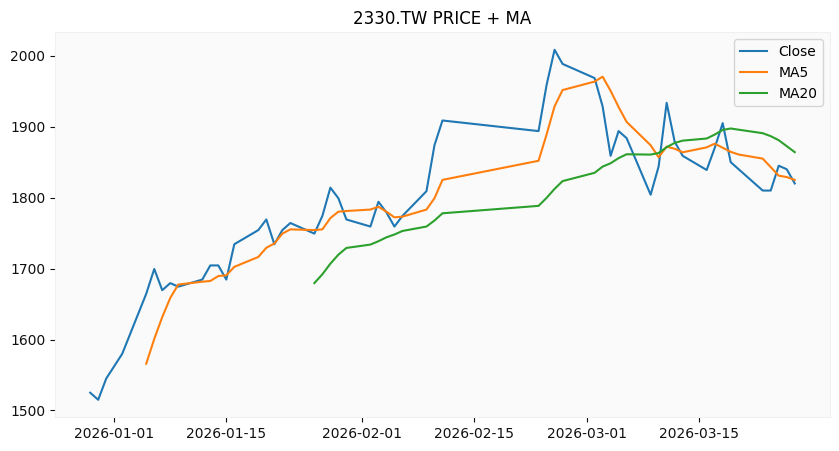



📊 下一張圖：成交量 (VOLUME)



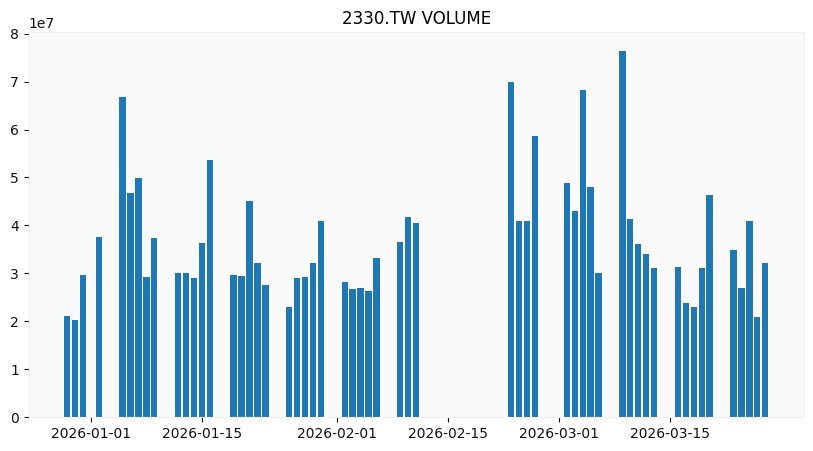



📉 下一張圖：RSI 指標



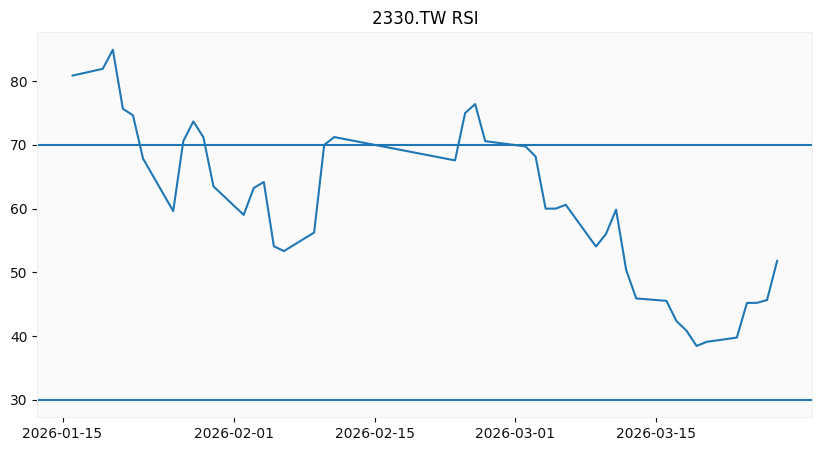



📊 下一張圖：MACD 指標



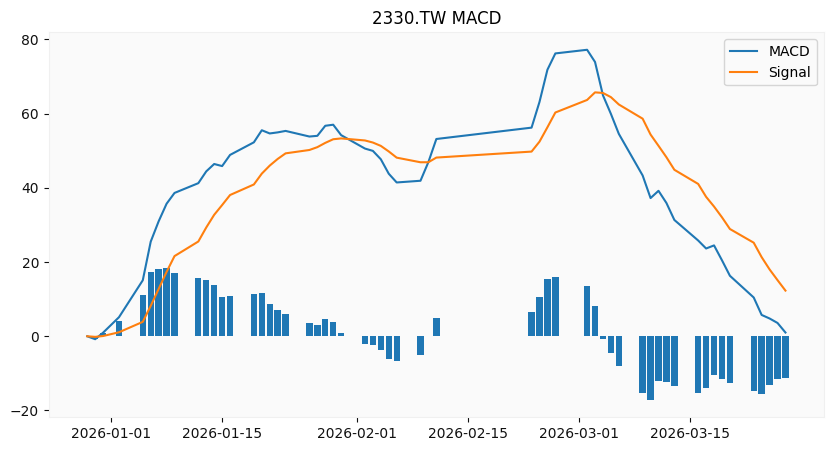



🕯️ 下一張圖：K線圖 (CANDLESTICK)



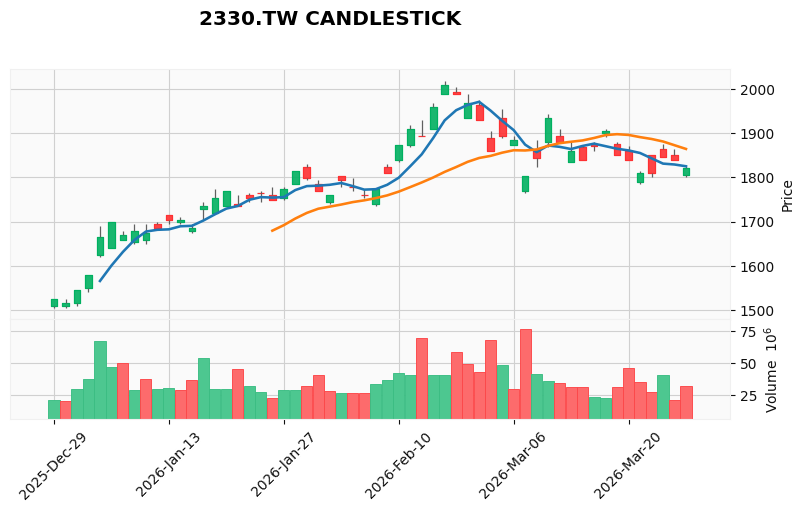


📊 分析結果
Score: -1
👉 HOLD
- 下降趨勢（MA5 < MA20）
- 未過熱（RSI < 70）
- 動能轉弱（MACD < Signal）

📊 ANALYSIS FOR 2454.TW


📈 下一張圖：價格 + 移動平均線 (MA)



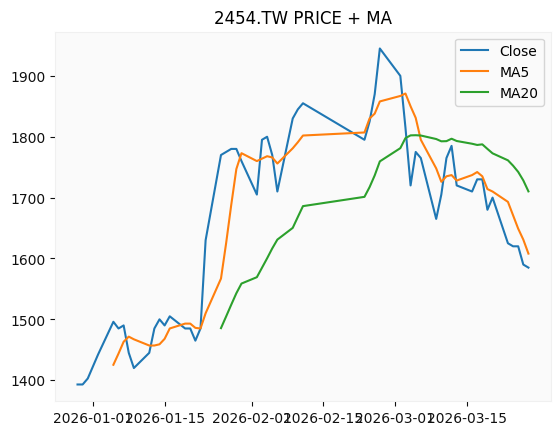



📊 下一張圖：成交量 (VOLUME)



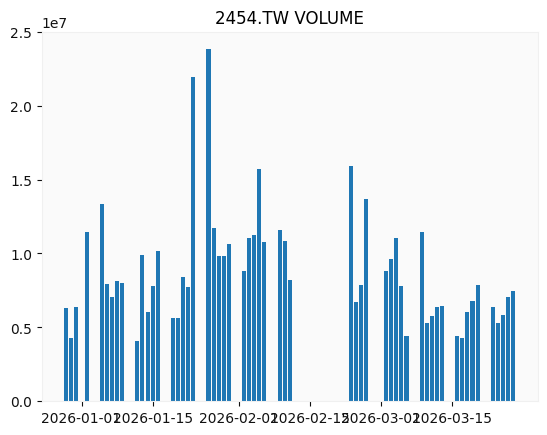



📉 下一張圖：RSI 指標



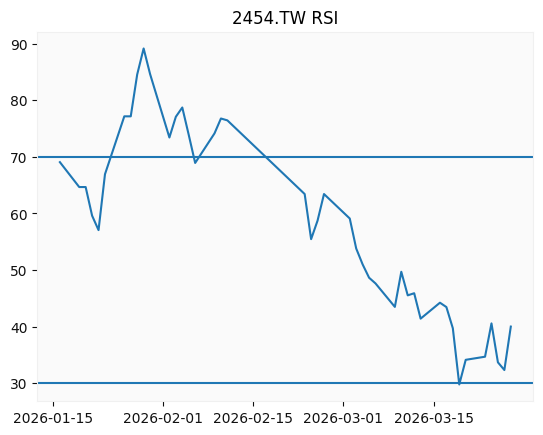



📊 下一張圖：MACD 指標



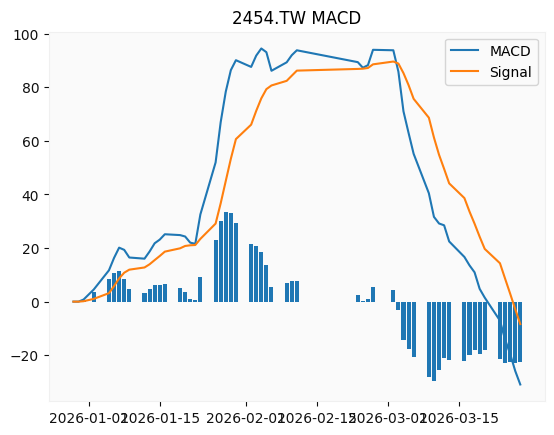



🕯️ 下一張圖：K線圖 (CANDLESTICK)



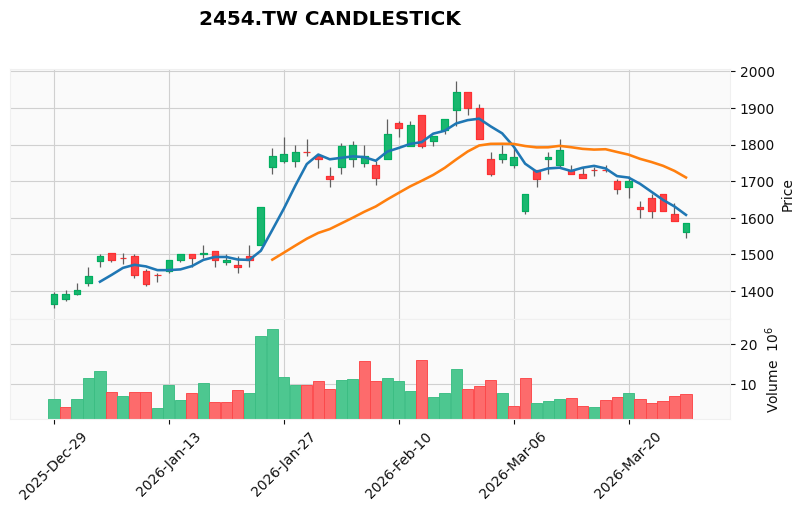


📊 分析結果
Score: -1
👉 HOLD
- 下降趨勢（MA5 < MA20）
- 未過熱（RSI < 70）
- 動能轉弱（MACD < Signal）

📊 ANALYSIS FOR 3035.TW


📈 下一張圖：價格 + 移動平均線 (MA)



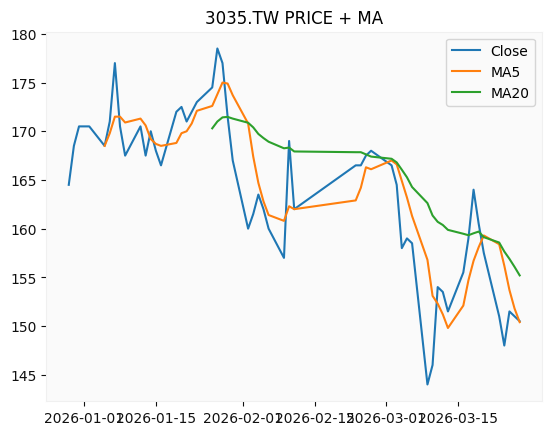



📊 下一張圖：成交量 (VOLUME)



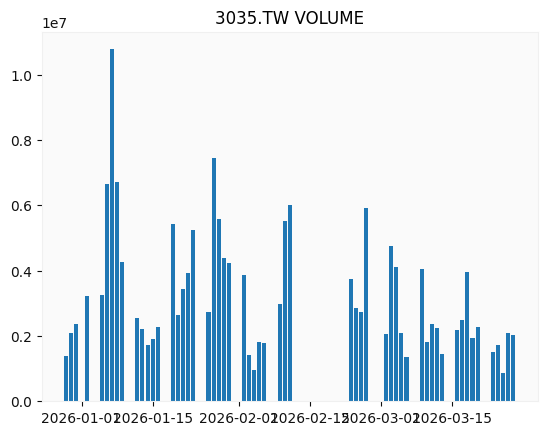



📉 下一張圖：RSI 指標



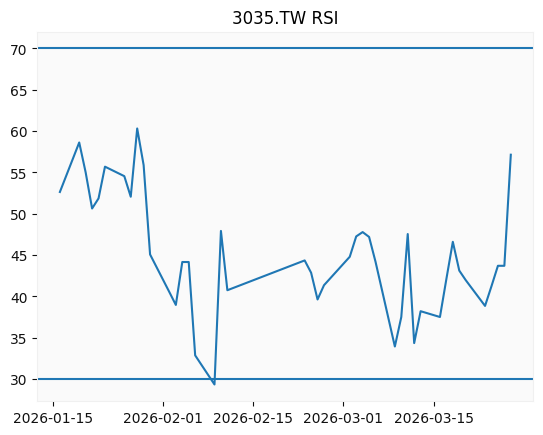



📊 下一張圖：MACD 指標



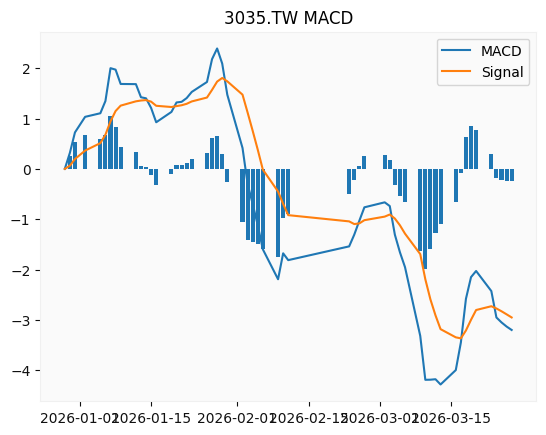



🕯️ 下一張圖：K線圖 (CANDLESTICK)



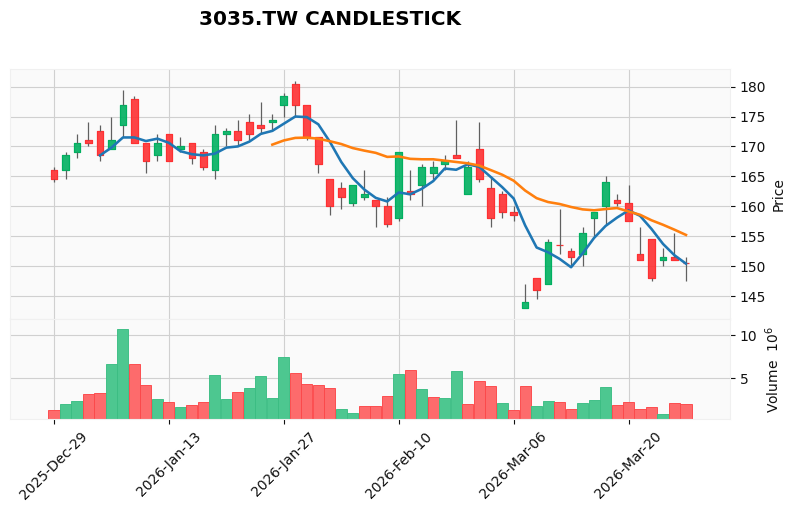


📊 分析結果
Score: -1
👉 HOLD
- 下降趨勢（MA5 < MA20）
- 未過熱（RSI < 70）
- 動能轉弱（MACD < Signal）

📊 FINAL RANKING
2330.TW → Score: -1
2454.TW → Score: -1
3035.TW → Score: -1


In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf

# =========================
# 統一圖大小（全域設定）
# =========================
plt.rcParams['figure.figsize'] = (10, 5)

# =========================
# RSI
# =========================
def calculate_rsi(data, window=14):
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

# =========================
# MACD
# =========================
def calculate_macd(data):
    ema12 = data['Close'].ewm(span=12, adjust=False).mean()
    ema26 = data['Close'].ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26
    signal = macd.ewm(span=9, adjust=False).mean()
    hist = macd - signal
    return macd, signal, hist

# =========================
# 評分系統
# =========================
def analyze_stock(df):
    latest = df.iloc[-1]
    score = 0
    reasons = []

    if latest['MA5'] > latest['MA20']:
        score += 1
        reasons.append("上升趨勢（MA5 > MA20）")
    else:
        score -= 1
        reasons.append("下降趨勢（MA5 < MA20）")

    if latest['RSI'] < 70:
        score += 1
        reasons.append("未過熱（RSI < 70）")
    else:
        score -= 1
        reasons.append("過熱（RSI > 70）")

    if latest['MACD'] > latest['Signal']:
        score += 1
        reasons.append("動能向上（MACD > Signal）")
    else:
        score -= 1
        reasons.append("動能轉弱（MACD < Signal）")

    return score, reasons

# =========================
# 使用者輸入股票
# =========================
user_input = input("請輸入股票代碼（例如 2330.TW,2454.TW,AAPL）：\n")
stocks = [s.strip() for s in user_input.split(",")]

results = []

# =========================
# 主程式
# =========================
for stock in stocks:

    print("\n====================================")
    print(f"📊 ANALYSIS FOR {stock}")
    print("====================================")

    ticker = yf.Ticker(stock)
    df = ticker.history(period="3mo")
    df = df[['Open','High','Low','Close','Volume']]

    # 技術指標
    df['MA5'] = df['Close'].rolling(5).mean()
    df['MA20'] = df['Close'].rolling(20).mean()
    df['RSI'] = calculate_rsi(df)

    macd, signal, hist = calculate_macd(df)
    df['MACD'] = macd
    df['Signal'] = signal
    df['Hist'] = hist

    # =========================
    # 圖1：價格 + MA
    # =========================
    print("\n\n📈 下一張圖：價格 + 移動平均線 (MA)\n")
    plt.figure()
    plt.plot(df.index, df['Close'], label='Close')
    plt.plot(df.index, df['MA5'], label='MA5')
    plt.plot(df.index, df['MA20'], label='MA20')
    plt.title(f"{stock} PRICE + MA")
    plt.legend()
    plt.grid()
    plt.show()
    plt.close()

    # =========================
    # 圖2：成交量
    # =========================
    print("\n\n📊 下一張圖：成交量 (VOLUME)\n")
    plt.figure()
    plt.bar(df.index, df['Volume'])
    plt.title(f"{stock} VOLUME")
    plt.grid()
    plt.show()
    plt.close()

    # =========================
    # 圖3：RSI
    # =========================
    print("\n\n📉 下一張圖：RSI 指標\n")
    plt.figure()
    plt.plot(df.index, df['RSI'])
    plt.axhline(70)
    plt.axhline(30)
    plt.title(f"{stock} RSI")
    plt.grid()
    plt.show()
    plt.close()

    # =========================
    # 圖4：MACD
    # =========================
    print("\n\n📊 下一張圖：MACD 指標\n")
    plt.figure()
    plt.plot(df.index, df['MACD'], label='MACD')
    plt.plot(df.index, df['Signal'], label='Signal')
    plt.bar(df.index, df['Hist'])
    plt.title(f"{stock} MACD")
    plt.legend()
    plt.grid()
    plt.show()
    plt.close()

    # =========================
    # K線圖
    # =========================
    print("\n\n🕯️ 下一張圖：K線圖 (CANDLESTICK)\n")
    df_k = df[['Open','High','Low','Close','Volume']]

    mpf.plot(
        df_k,
        type='candle',
        mav=(5,20),
        volume=True,
        style='yahoo',
        title=f"{stock} CANDLESTICK",
        figsize=(10,5)  # 統一大小
    )

    # =========================
    # 分析結果
    # =========================
    score, reasons = analyze_stock(df)

    print("\n📊 分析結果")
    print(f"Score: {score}")

    if score >= 2:
        print("👉 BUY")
    elif score <= -2:
        print("👉 AVOID")
    else:
        print("👉 HOLD")

    for r in reasons:
        print("-", r)

    results.append((stock, score))

# =========================
# 最終排名
# =========================
print("\n====================================")
print("📊 FINAL RANKING")
print("====================================")

results.sort(key=lambda x: x[1], reverse=True)

for stock, score in results:
    print(f"{stock} → Score: {score}")